Classification

In [1]:
from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

In [2]:
dataset = datasets.load_breast_cancer()
X = dataset.data
y = dataset.target

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [4]:
clf_tree = DecisionTreeClassifier();
clf_tree.fit(X_train, y_train); 


In [5]:
y_pred = clf_tree.predict(X_test)
print(y_pred)

[1 0 0 1 0 1 0 0 1 1 0 1 1 0 1 0 0 1 1 1 0 1 0 0 1 1 1 1 1 1 0 1 0 1 0 1 1
 0 0 1 1 1 1 1 0 0 0 1 1 1 0 1 0 0 1 0 0 1 1 1 1 1 0 1 1 1 1 0 1 0 1 1 0 0
 0 1 1 1 1 0 1 1 0 1 1 0 0 1 1 1 1 0 0 1 1 0 1 0 1 1 1 1 1 1 1 0 0 1 1 1 1
 0 1 0]


Evaluation Metrics

In [6]:
from sklearn.metrics import confusion_matrix
tn, fp, fn, tp = confusion_matrix(y_test,y_pred).ravel()
print("True Negatives {}".format(tn))
print("False Negatives {}".format(fn))
print("True Positives {}".format(tp))
print("False Positives {}".format(fp))


True Negatives 39
False Negatives 4
True Positives 67
False Positives 4


In [7]:
acc = (tn+tp)/(tn+tp+fn+fp)
print("Accuracy {}".format(acc))

Accuracy 0.9298245614035088


In [8]:
error_rate = (fn+fp)/(tn+tp+fn+fp)
print("Error Rate {}".format(error_rate))


Error Rate 0.07017543859649122


In [9]:
precision = tp/(tp+fp)
print("Precision {}".format(precision))

Precision 0.9436619718309859


In [10]:
sns = tp/(tp+fn)
spc = tn/(tn+fp)
print("Sensitivity {}".format(sns))
print("Specificity {}".format(spc))

Sensitivity 0.9436619718309859
Specificity 0.9069767441860465


In [11]:
import math
roc = math.sqrt((sns*sns)+(spc*spc))/math.sqrt(2)
print("ROC {}".format(roc))

ROC 0.9255011430501491


In [12]:
GM = math.sqrt(sns*spc)
print("Geometric Mean {}".format(GM))

Geometric Mean 0.9251375372470043


In [13]:
f1 = (2*sns*precision)/(precision+sns)
print("f1 score {}".format(f1))

f1 score 0.9436619718309859


In [14]:
fpr = 1-spc
fnr = 1 -sns
power = 1 - fnr
print("False positive Rate {}".format(fpr))
print("false negative Rate {}".format(fnr))
print("Power {}".format(power))

False positive Rate 0.09302325581395354
false negative Rate 0.05633802816901412
Power 0.9436619718309859


**ROC**

AUC Score: 0.9253193580085163


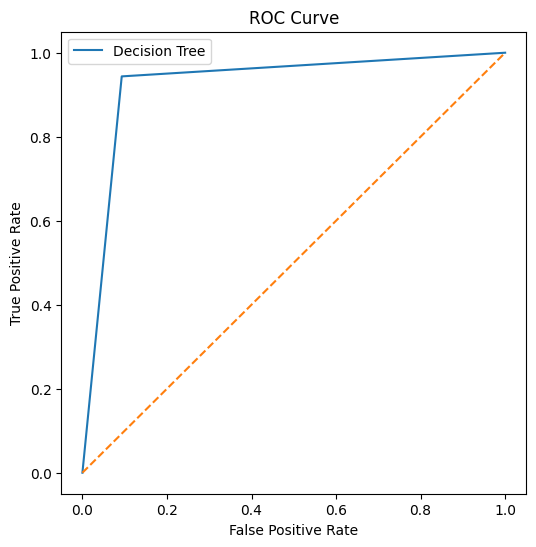

In [18]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_test, y_pred)

print("AUC Score:", roc_auc_score(y_test, y_pred))

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label="Decision Tree")
plt.plot([0,1], [0,1], '--')   # baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

**Regression**

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression

df = pd.read_excel("regdata.xlsx")

# Log transform
df['log_price'] = np.log(df['Price'])
df['log_demand'] = np.log(df['Dem'])

# Plot
sns.regplot(x='log_price', y='log_demand', data=df)

# Model
X = df[['log_price']]
y = df['log_demand']

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

**Eval Metrics**

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from scipy.stats import pearsonr
import numpy as np

# Correlation
corr, _ = pearsonr(df['log_price'], df['log_demand'])
print("Correlation:", round(corr,3))

# Errors
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred)

# R2
r2 = r2_score(y, y_pred)

# MAPE
mape = np.mean(np.abs((y - y_pred)/y)) * 100

print("MSE:", mse)
print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)
print("MAPE:", mape)